假设我们不以全年为测试集,这样我们尽可能利用最近的时间作为验证集,选一个好的种子.将每个月的折线连起来.是否能进行改进?

# 2020逐月回测：前三个月验证选种子，堆叠各100轮

沿用11最后的两阶段Stacking：第一阶段原7变量→股价；第二阶段第一阶段预测＋金铜昨日涨幅、相对5/20期均价涨幅→股价。两阶段均16→32隐藏层、ReLU、Adam学习率0.01、全批量、各100轮；样本内堆叠，不用折外预测。

候选种子随机抽取10个、排除旧实验种子，并在训练前冻结；全年每月使用相同候选，便于比較。下面代码直接保存具体种子，重新运行不会再次抽样。

每个预测月M：训练数据为验证期开始以前的全部历史；验证期为M前连续3个日历月；测试为M当月。例如2020年1月：训练截至2019-09-30，验证2019-10-01至2019-12-31，测试2020-01-01至2020-01-31。2月训练截至2019-10-31，验证2019年11月至2020年1月，测试2月，依次滚动。此前已发生的月份可以进入后续验证/训练，但未来月份不能进入。

只按验证MAPE最低选择种子，精确并列按固定候选顺序。锁定后不加入验证集重训。选择记录先落盘，再评估当月测试。拼接12个月后报告逐记录全年MAPE（等价于按样本数加权的月MAPE）和12个月等权平均MAPE。

对照：把1月验证选中的同一模型全年冻结，在相同2020日期评估，比较逐月更新是否改善。此对照与1月滚动结果必须一致。两种方案同起点、同候选，比较的变化包括每月扩大训练数据与更新验证/选择，并非单独检验某一个因素。

**时间可用性限制**：输入包含同日金铜价格等，因此是逐月更新模型的同日股价样本外回测，不能称为月初已知整个未来月的预测。此前已查看过2020年，属于历史开发实验，不是全新盲测。滚动均价包括当天、窗口按记录计数，未重新修改原Dataset对齐方式。


In [1]:
from pathlib import Path
import os,json,hashlib,random
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display,Image
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP12_OUT',str(ROOT/'results/mlp_monthly_validation_12')));OUT.mkdir(parents=True,exist_ok=True)
SEEDS=[965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]
EXCLUDED_SEEDS=[0, 1, 7, 21, 42, 100, 123, 999, 2024, 2025]
EPOCHS=100;LR=0.01;VALIDATION_MONTHS=3
torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
assert len(set(SEEDS))==10 and not set(SEEDS)&set(EXCLUDED_SEEDS)
dataset=ROOT/'src/pickle/Dataset.pkl';d=pd.read_pickle(dataset)
raw=d['X'].copy();target=d['Y'].copy();assert raw.index.equals(target.index)
assert raw.index.is_unique and raw.index.is_monotonic_increasing
raw=raw.loc[raw.index<'2021-01-01'];BASE=list(raw.columns);assert len(BASE)==7
y=pd.Series(np.asarray(target).reshape(-1),index=target.index,name='Actual').loc[raw.index]
x=raw.copy();RETURNS=[]
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    name=f'{metal}_daily';x[name]=raw[col]/raw[col].shift(1)-1;RETURNS.append(name)
    for k in [5,20]:
        name=f'{metal}_vs_ma{k}';x[name]=raw[col]/raw[col].rolling(k,min_periods=k).mean()-1;RETURNS.append(name)
valid=np.isfinite(x.to_numpy()).all(axis=1)&np.isfinite(y.to_numpy())
x=x.loc[valid];y=y.loc[x.index];assert (y>0).all()
whole=x.index[x.index.year==2020];assert len(whole)==271
config=dict(seeds=SEEDS,excluded_prior_seeds=EXCLUDED_SEEDS,epochs_per_stage=EPOCHS,validation_months=VALIDATION_MONTHS,hidden=[16,32],activation='ReLU',optimizer='Adam',lr=LR,batch='full',base_features=BASE,stage2_features=['base_prediction']+RETURNS,stage2_training='in-sample predictions; base frozen',refit_after_selection=False,target='same-date original price',selection='minimum preceding-three-calendar-month MAPE; ties by candidate order',test_year=2020,dataset_sha256=hashlib.sha256(dataset.read_bytes()).hexdigest(),torch_version=str(torch.__version__))
(OUT/'config.json').write_text(json.dumps(config,ensure_ascii=False,indent=2))
x.join(y).to_csv(OUT/'features_and_target.csv',index_label='Date')
print('Frozen candidate seeds:',SEEDS)


Frozen candidate seeds: [965409, 640934, 550343, 798291, 374583, 42716, 785634, 565766, 385735, 741131]


In [2]:
history=[]
def fit_stage(X,train_idx,seed,stage,month):
    random.seed(seed);np.random.seed(seed);torch.manual_seed(seed)
    sx=StandardScaler().fit(X.loc[train_idx]);sy=StandardScaler().fit(y.loc[train_idx].to_numpy().reshape(-1,1))
    xt=torch.tensor(sx.transform(X.loc[train_idx]),dtype=torch.float32);yt=torch.tensor(sy.transform(y.loc[train_idx].to_numpy().reshape(-1,1)),dtype=torch.float32)
    model=nn.Sequential(nn.Linear(X.shape[1],16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    opt=torch.optim.Adam(model.parameters(),lr=LR)
    for epoch in range(1,EPOCHS+1):
        model.train();opt.zero_grad();loss=((model(xt)-yt)**2).mean();assert torch.isfinite(loss)
        loss.backward();opt.step();model.eval()
        with torch.no_grad():z=model(xt).numpy()
        p=sy.inverse_transform(z).ravel();mse=float(np.mean((p-y.loc[train_idx].to_numpy())**2))
        history.append(dict(Month=month,Seed=seed,Stage=stage,Epoch=epoch,Train_MSE=mse,Train_MSE_standardized=mse/float(sy.scale_[0]**2)))
    torch.save(dict(state_dict=model.state_dict(),features=list(X.columns),seed=seed,epochs=EPOCHS,train_start=str(train_idx.min()),train_end=str(train_idx.max()),sx_mean=sx.mean_.tolist(),sx_scale=sx.scale_.tolist(),sy_mean=sy.mean_.tolist(),sy_scale=sy.scale_.tolist()),OUT/f'{month}_{stage}_seed{seed}.pt')
    return model,sx,sy

def predict(bundle,X):
    model,sx,sy=bundle;model.eval()
    with torch.no_grad():z=model(torch.tensor(sx.transform(X),dtype=torch.float32)).numpy()
    p=sy.inverse_transform(z).ravel();assert np.isfinite(p).all();return pd.Series(p,index=X.index)

def score(pred,idx):
    err=pred.loc[idx].to_numpy()-y.loc[idx].to_numpy()
    return dict(N=len(idx),MAPE=float(100*np.mean(np.abs(err)/np.abs(y.loc[idx].to_numpy()))),MSE=float(np.mean(err**2)))

def stack_predict(base,stack,X):
    bp=predict(base,X[BASE]);meta=X[RETURNS].copy();meta.insert(0,'base_prediction',bp)
    return predict(stack,meta)

splitrows=[];valrows=[];testrows=[];selections=[];testframes=[];valframes=[];trainrows=[];selectedframes=[]
for month_start in pd.date_range('2020-01-01','2020-12-01',freq='MS'):
    month=month_start.strftime('%Y-%m');val_start=month_start-pd.DateOffset(months=VALIDATION_MONTHS);month_end=month_start+pd.DateOffset(months=1)
    tr=x.index[x.index<val_start];va=x.index[(x.index>=val_start)&(x.index<month_start)];te=x.index[(x.index>=month_start)&(x.index<month_end)]
    assert len(tr)>0 and len(va)>0 and len(te)>0 and tr.max()<va.min() and va.max()<te.min()
    for split,idx in [('Train',tr),('Validation',va),('Test',te)]:
        splitrows.append(dict(Month=month,Split=split,N=len(idx),Start=str(idx.min().date()),End=str(idx.max().date())))
    # Candidate fitting and ranking do not access target-month labels.
    known=x.loc[x.index<month_start];bundles={};monthvals=[]
    for i,seed in enumerate(SEEDS):
        base=fit_stage(known[BASE],tr,seed,'Base',month)
        bp=predict(base,known[BASE]);meta=known[RETURNS].copy();meta.insert(0,'base_prediction',bp)
        stack=fit_stage(meta,tr,seed,'Stacking',month);bundles[seed]=(base,stack)
        vp=predict(stack,meta)
        monthvals.append(dict(Month=month,Seed=seed,Candidate_order=i,**score(vp,va)))
        trainrows.append(dict(Month=month,Seed=seed,**score(vp,tr)))
        valframes.append(pd.DataFrame(dict(Date=va,Month=month,Seed=seed,Actual=y.loc[va].to_numpy(),Predicted=vp.loc[va].to_numpy())))
    ranking=pd.DataFrame(monthvals).sort_values(['MAPE','Candidate_order']).reset_index(drop=True)
    ranking['Rank']=np.arange(1,len(ranking)+1);chosen=int(ranking.iloc[0].Seed);ranking['Selected']=ranking.Seed.eq(chosen)
    valrows.extend(ranking.to_dict('records'))
    decision=dict(Month=month,Selected_seed=chosen,Validation_MAPE=float(ranking.iloc[0].MAPE),Train_end=str(tr.max().date()),Validation_start=str(va.min().date()),Validation_end=str(va.max().date()),Test_start=str(te.min().date()),Test_end=str(te.max().date()),Refit=False)
    # Lock and persist before any target-month evaluation.
    (OUT/f'{month}_selection.json').write_text(json.dumps(decision,ensure_ascii=False,indent=2));selections.append(decision)
    if month=='2020-01':annual_base,annual_stack=bundles[chosen];annual_seed=chosen
    for seed in SEEDS:
        base,stack=bundles[seed];pred=stack_predict(base,stack,x.loc[te]);metrics=score(pred,te)
        testrows.append(dict(Month=month,Seed=seed,Selected=seed==chosen,**metrics))
        frame=pd.DataFrame(dict(Date=te,Month=month,Seed=seed,Actual=y.loc[te].to_numpy(),Predicted=pred.to_numpy()))
        testframes.append(frame)
        if seed==chosen:selectedframes.append(frame)
    print(f'{month}: selected seed {chosen}, validation MAPE {decision["Validation_MAPE"]:.3f}%',flush=True)

validation=pd.DataFrame(valrows);test_metrics=pd.DataFrame(testrows);selection=pd.DataFrame(selections)
stitched=pd.concat(selectedframes,ignore_index=True).sort_values('Date');stitched['APE']=100*np.abs(stitched.Predicted-stitched.Actual)/stitched.Actual.abs()
assert pd.DatetimeIndex(stitched.Date).equals(whole) and stitched.Date.is_unique
assert len(history)==12*10*2*100 and len(validation)==120 and len(test_metrics)==120
for m,g in validation.groupby('Month'):
    assert int(g.sort_values('Rank').iloc[0].Seed)==int(selection.loc[selection.Month==m,'Selected_seed'].iloc[0])
annual_pred=stack_predict(annual_base,annual_stack,x.loc[whole])
stitched['Frozen_annual_prediction']=annual_pred.to_numpy()
stitched['Frozen_annual_APE']=100*np.abs(stitched.Frozen_annual_prediction-stitched.Actual)/stitched.Actual.abs()
jan=stitched.Month=='2020-01';assert np.allclose(stitched.loc[jan,'Predicted'],stitched.loc[jan,'Frozen_annual_prediction'],rtol=0,atol=1e-6)
monthly=selection.merge(test_metrics[test_metrics.Selected][['Month','N','MAPE','MSE']].rename(columns={'MAPE':'Test_MAPE','MSE':'Test_MSE'}),on='Month',validate='one_to_one')
monthly=monthly.merge(stitched.groupby('Month').Frozen_annual_APE.mean().rename('Frozen_annual_MAPE'),on='Month',validate='one_to_one')
monthly['Rolling_minus_frozen_pp']=monthly.Test_MAPE-monthly.Frozen_annual_MAPE
summary=pd.DataFrame([dict(Method='Monthly validation selection',Annual_daily_MAPE=stitched.APE.mean(),Monthly_equal_MAPE=monthly.Test_MAPE.mean(),Annual_MSE=np.mean((stitched.Predicted-stitched.Actual)**2)),dict(Method='January selected model frozen all year',Annual_daily_MAPE=stitched.Frozen_annual_APE.mean(),Monthly_equal_MAPE=monthly.Frozen_annual_MAPE.mean(),Annual_MSE=np.mean((stitched.Frozen_annual_prediction-stitched.Actual)**2))])
assert np.isclose(stitched.APE.mean(),np.average(monthly.Test_MAPE,weights=monthly.N))
for name,frame in [('splits',pd.DataFrame(splitrows)),('validation_ranking',validation),('test_metrics_all_candidates',test_metrics),('train_metrics',pd.DataFrame(trainrows)),('selection',selection),('stitched_predictions',stitched),('monthly_results',monthly),('summary',summary),('training_history',pd.DataFrame(history)),('candidate_test_predictions',pd.concat(testframes,ignore_index=True)),('candidate_validation_predictions',pd.concat(valframes,ignore_index=True))]:frame.to_csv(OUT/f'{name}.csv',index=False)
print('Monthly selection and test results:');display(monthly[['Month','Selected_seed','Validation_MAPE','Test_MAPE','Frozen_annual_MAPE','Rolling_minus_frozen_pp']].round(4))
print('Annual comparison:');display(summary.round(4))


,Month,Selected_seed,Validation_MAPE,Test_MAPE,Frozen_annual_MAPE,Rolling_minus_frozen_pp
0,2020-01,785634,6.0256,12.4420,12.4420,0.0000
1,2020-02,785634,9.2545,14.2954,12.9335,1.3619
2,2020-03,785634,12.5468,5.6804,7.9675,-2.2871
3,2020-04,798291,6.7915,3.7448,3.1950,0.5499
4,2020-05,741131,4.5831,3.6497,5.3179,-1.6682
5,2020-06,741131,4.6159,13.3628,8.4461,4.9167
6,2020-07,965409,2.9153,13.3470,5.6452,7.7018
7,2020-08,798291,3.8530,7.6893,14.3553,-6.6659
8,2020-09,565766,5.6801,14.5983,22.2193,-7.6211
9,2020-10,42716,8.8443,12.4556,20.5544,-8.0989


,Method,Annual_daily_MAPE,Monthly_equal_MAPE,Annual_MSE
0,Monthly validation selection,11.5270,11.5536,0.7955
1,January selected model frozen all year,14.5383,14.6069,1.7473


2020-01: selected seed 785634, validation MAPE 6.026%
2020-02: selected seed 785634, validation MAPE 9.254%
2020-03: selected seed 785634, validation MAPE 12.547%
2020-04: selected seed 798291, validation MAPE 6.791%
2020-05: selected seed 741131, validation MAPE 4.583%
2020-06: selected seed 741131, validation MAPE 4.616%
2020-07: selected seed 965409, validation MAPE 2.915%
2020-08: selected seed 798291, validation MAPE 3.853%
2020-09: selected seed 565766, validation MAPE 5.680%
2020-10: selected seed 42716, validation MAPE 8.844%
2020-11: selected seed 385735, validation MAPE 8.294%
2020-12: selected seed 965409, validation MAPE 10.996%
Monthly selection and test results:
Annual comparison:


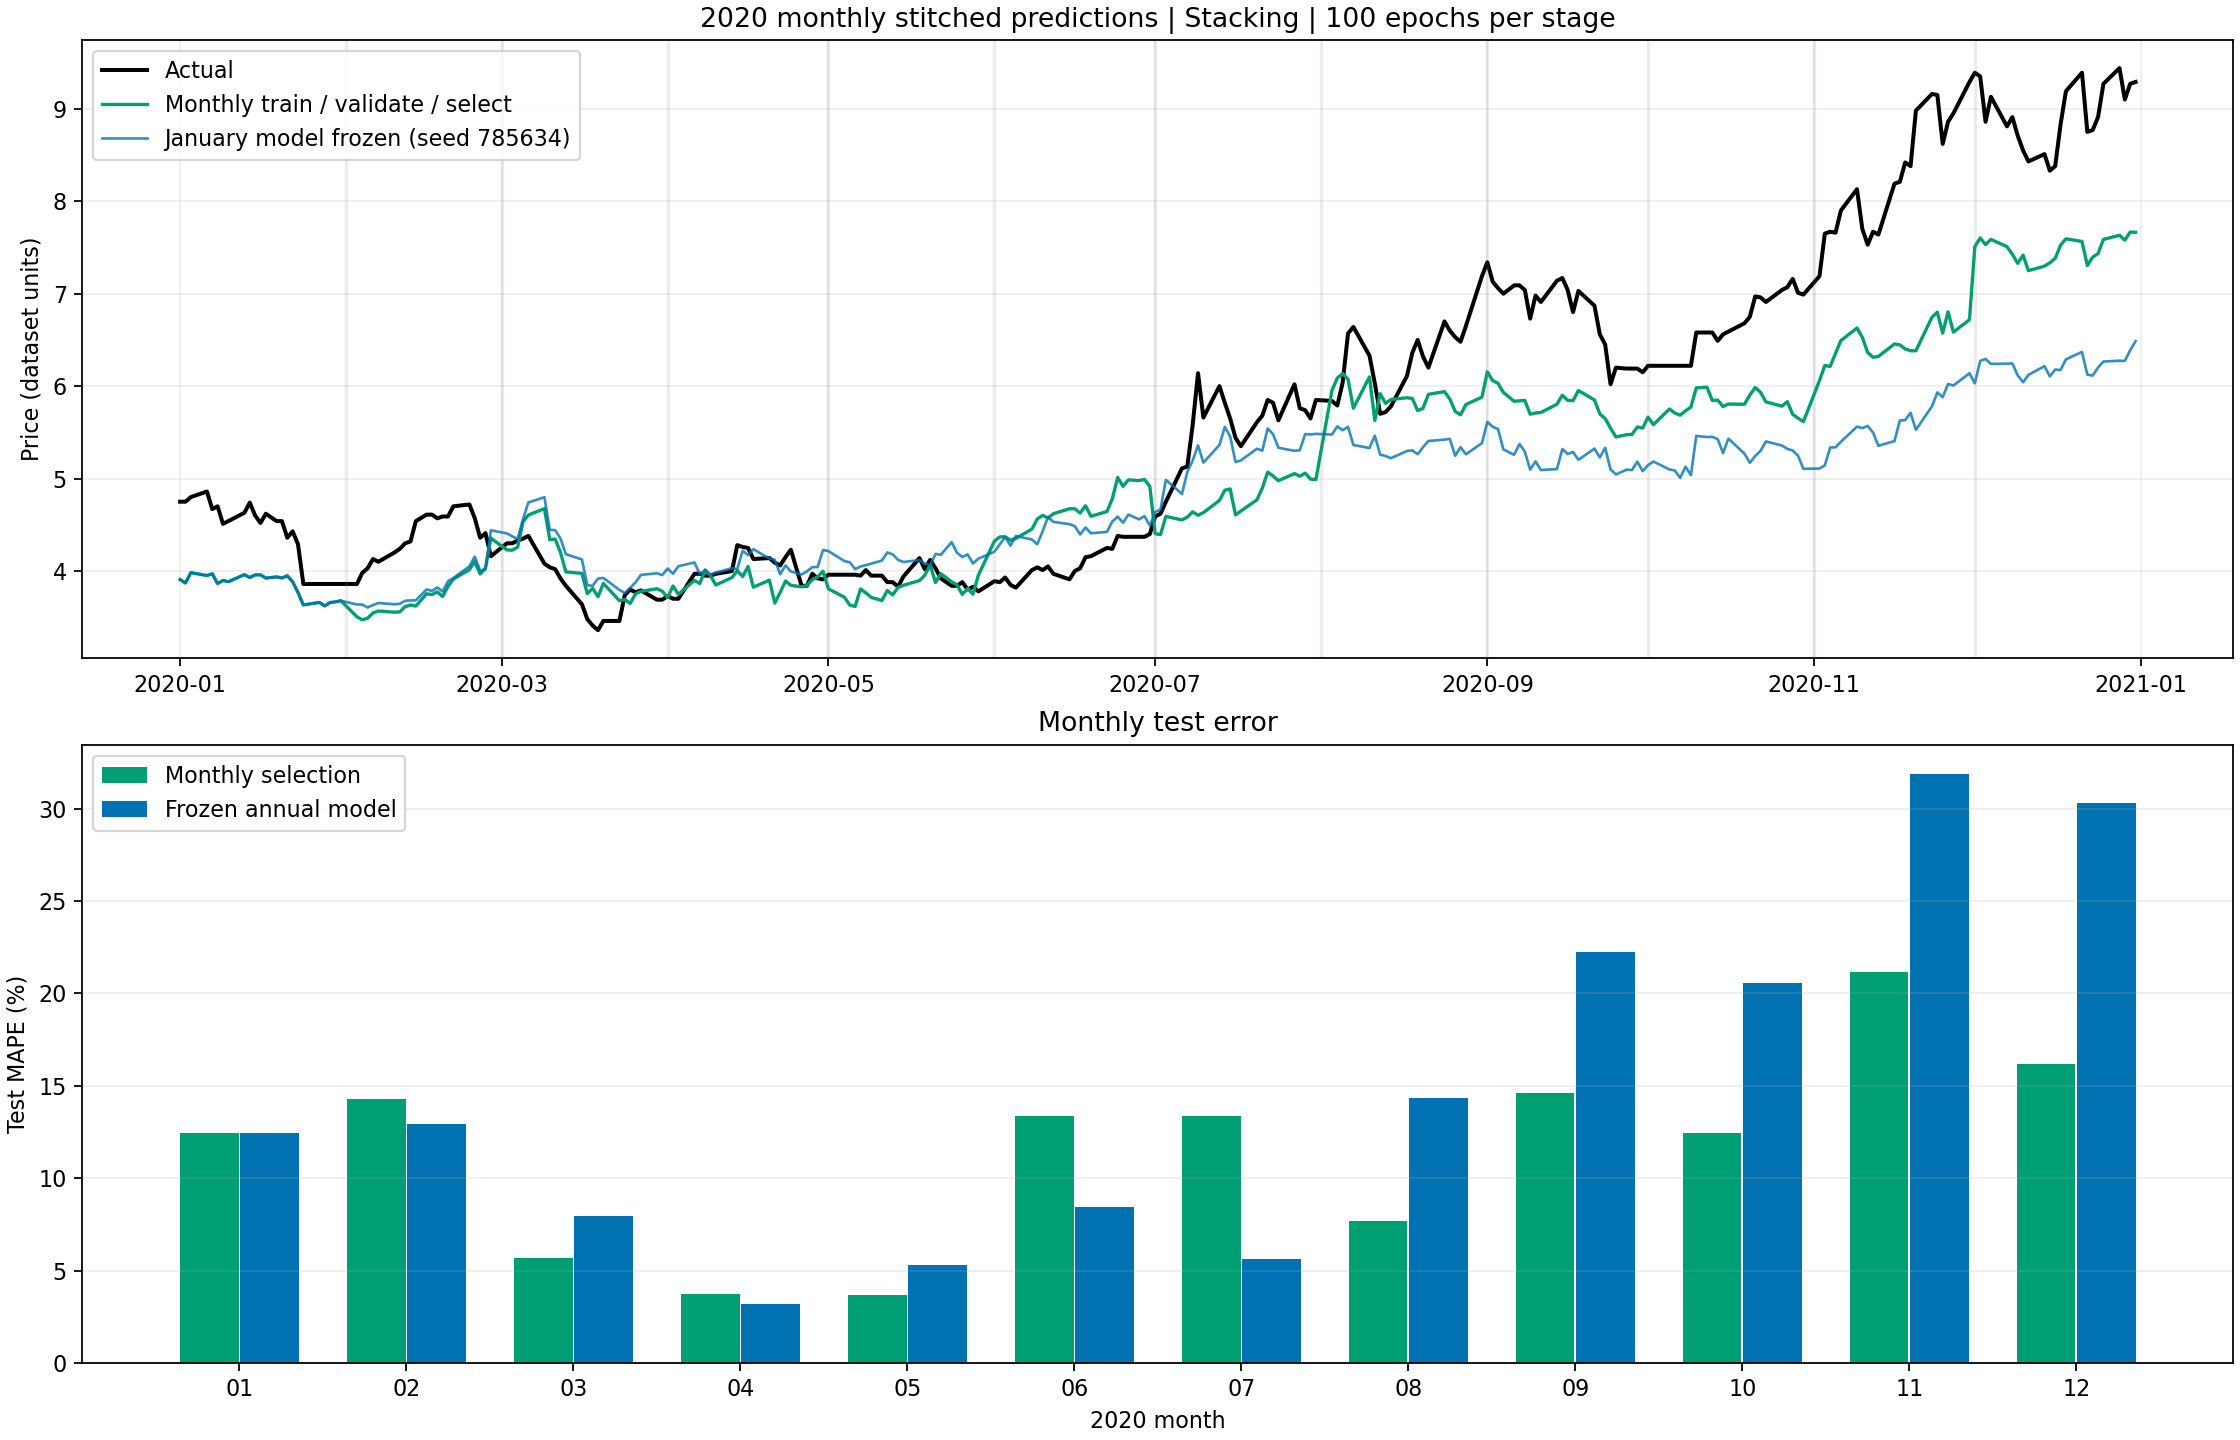

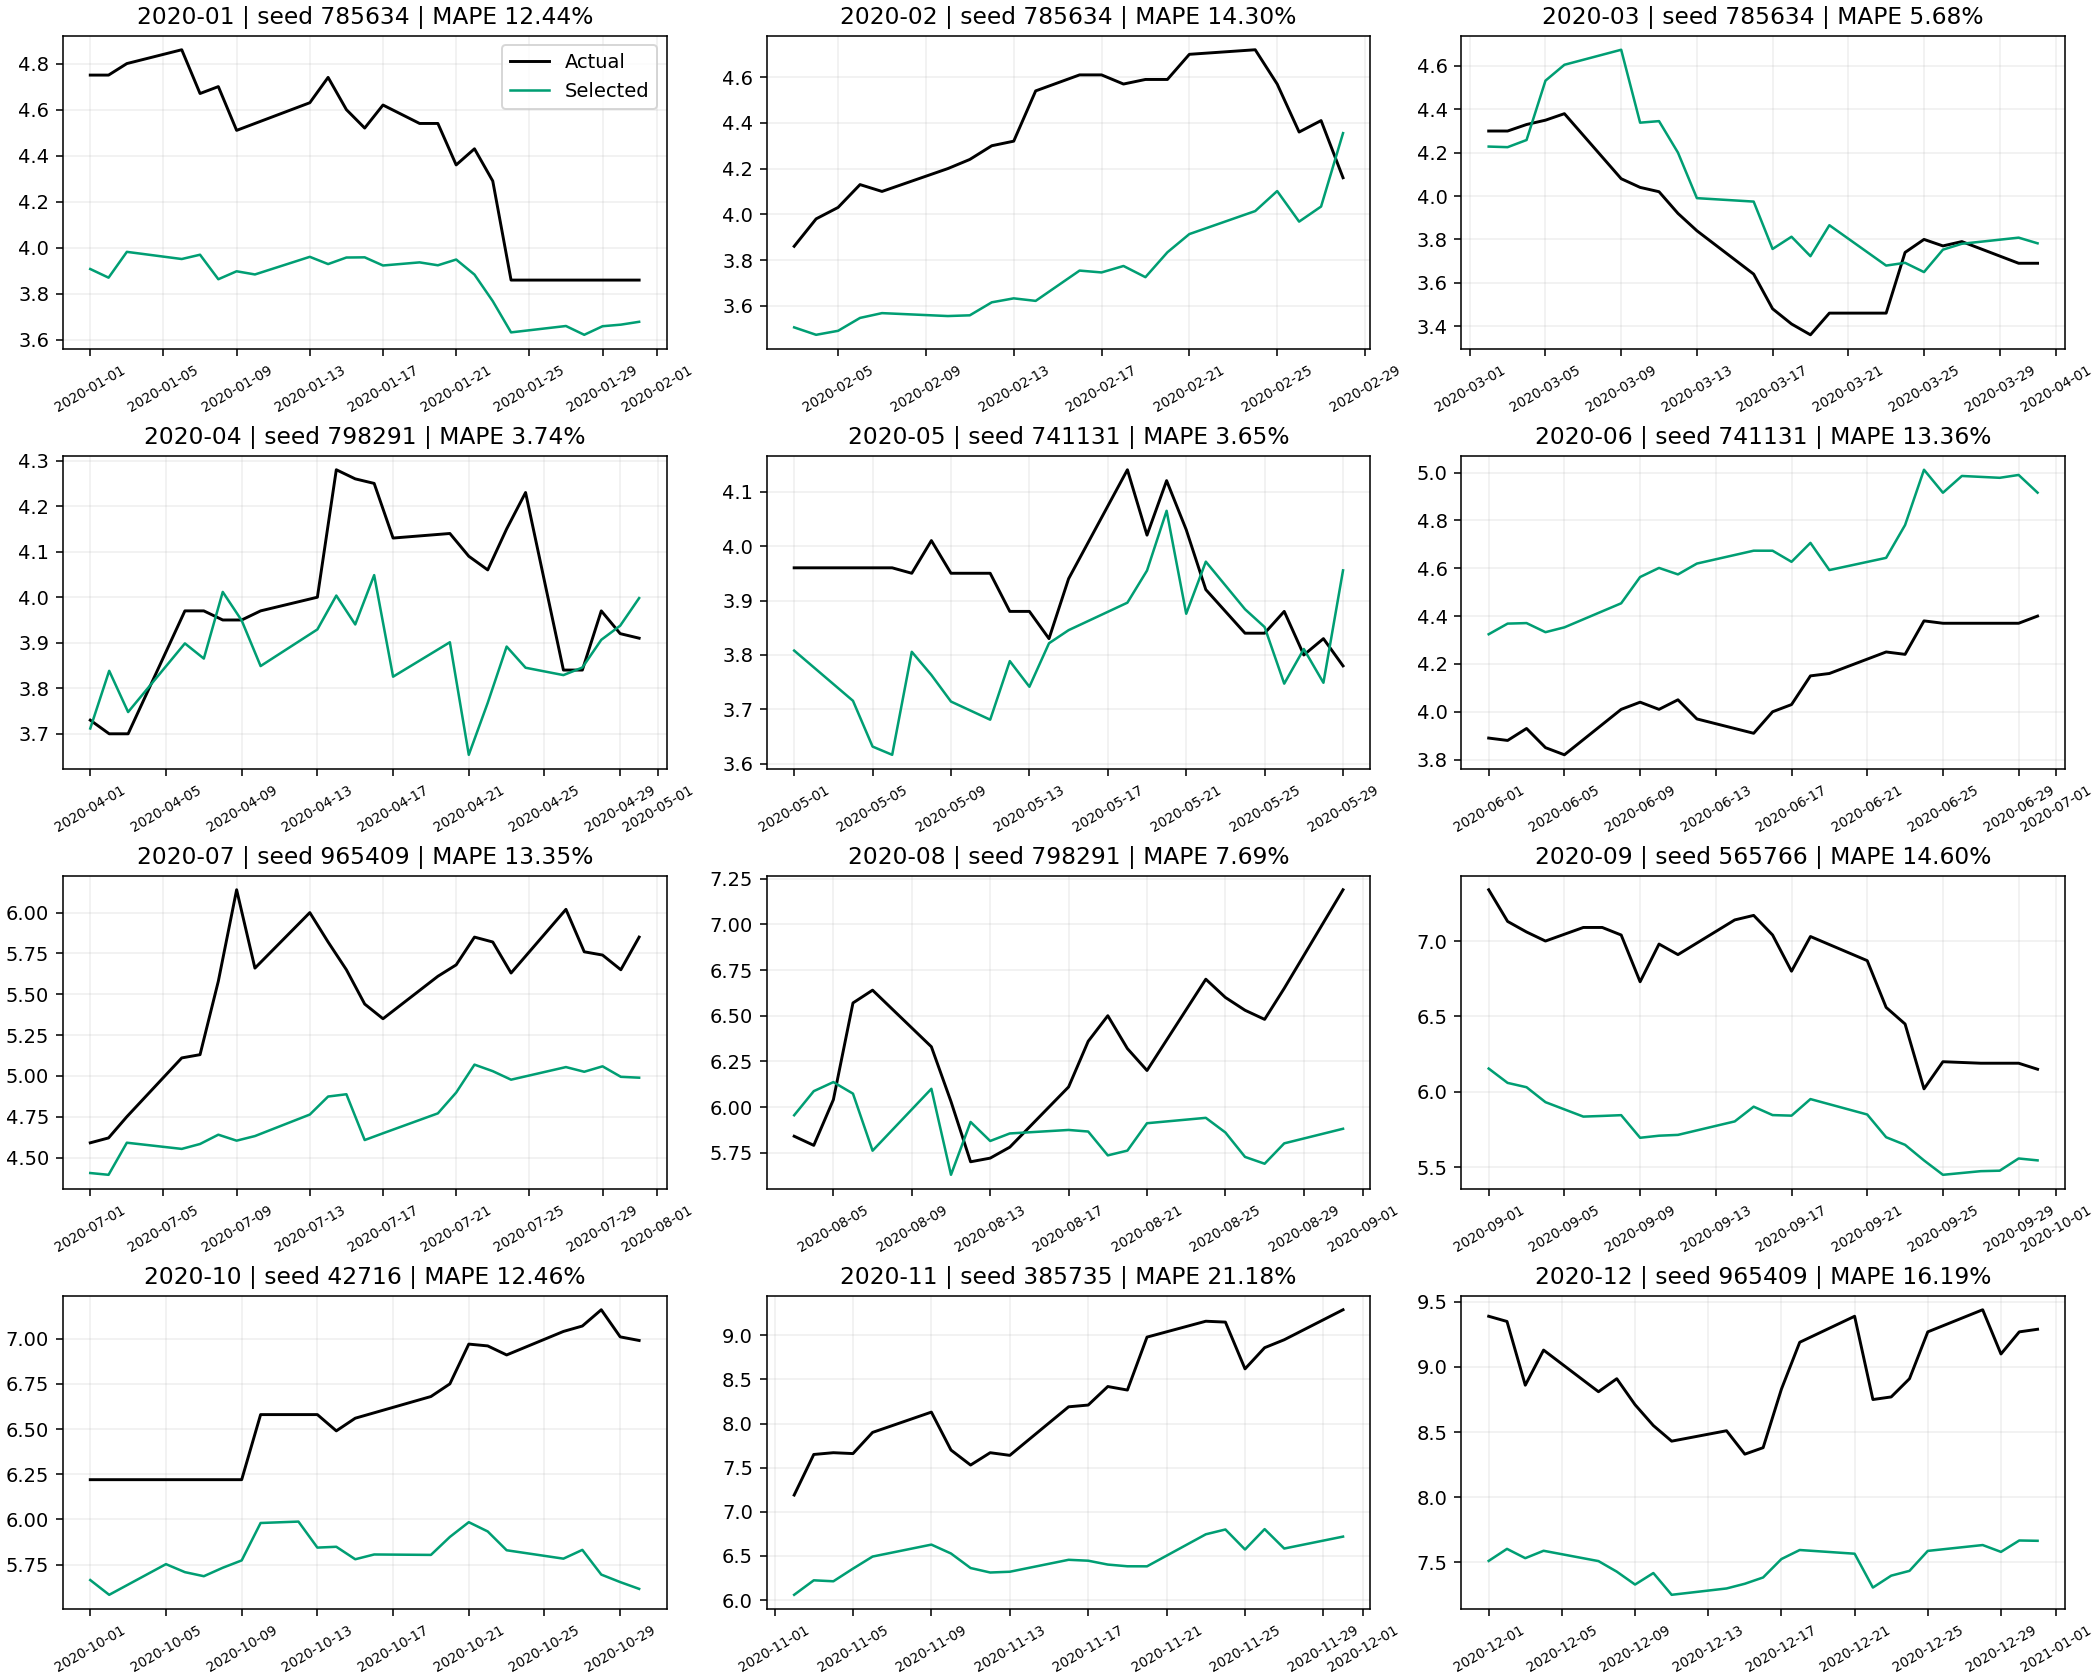

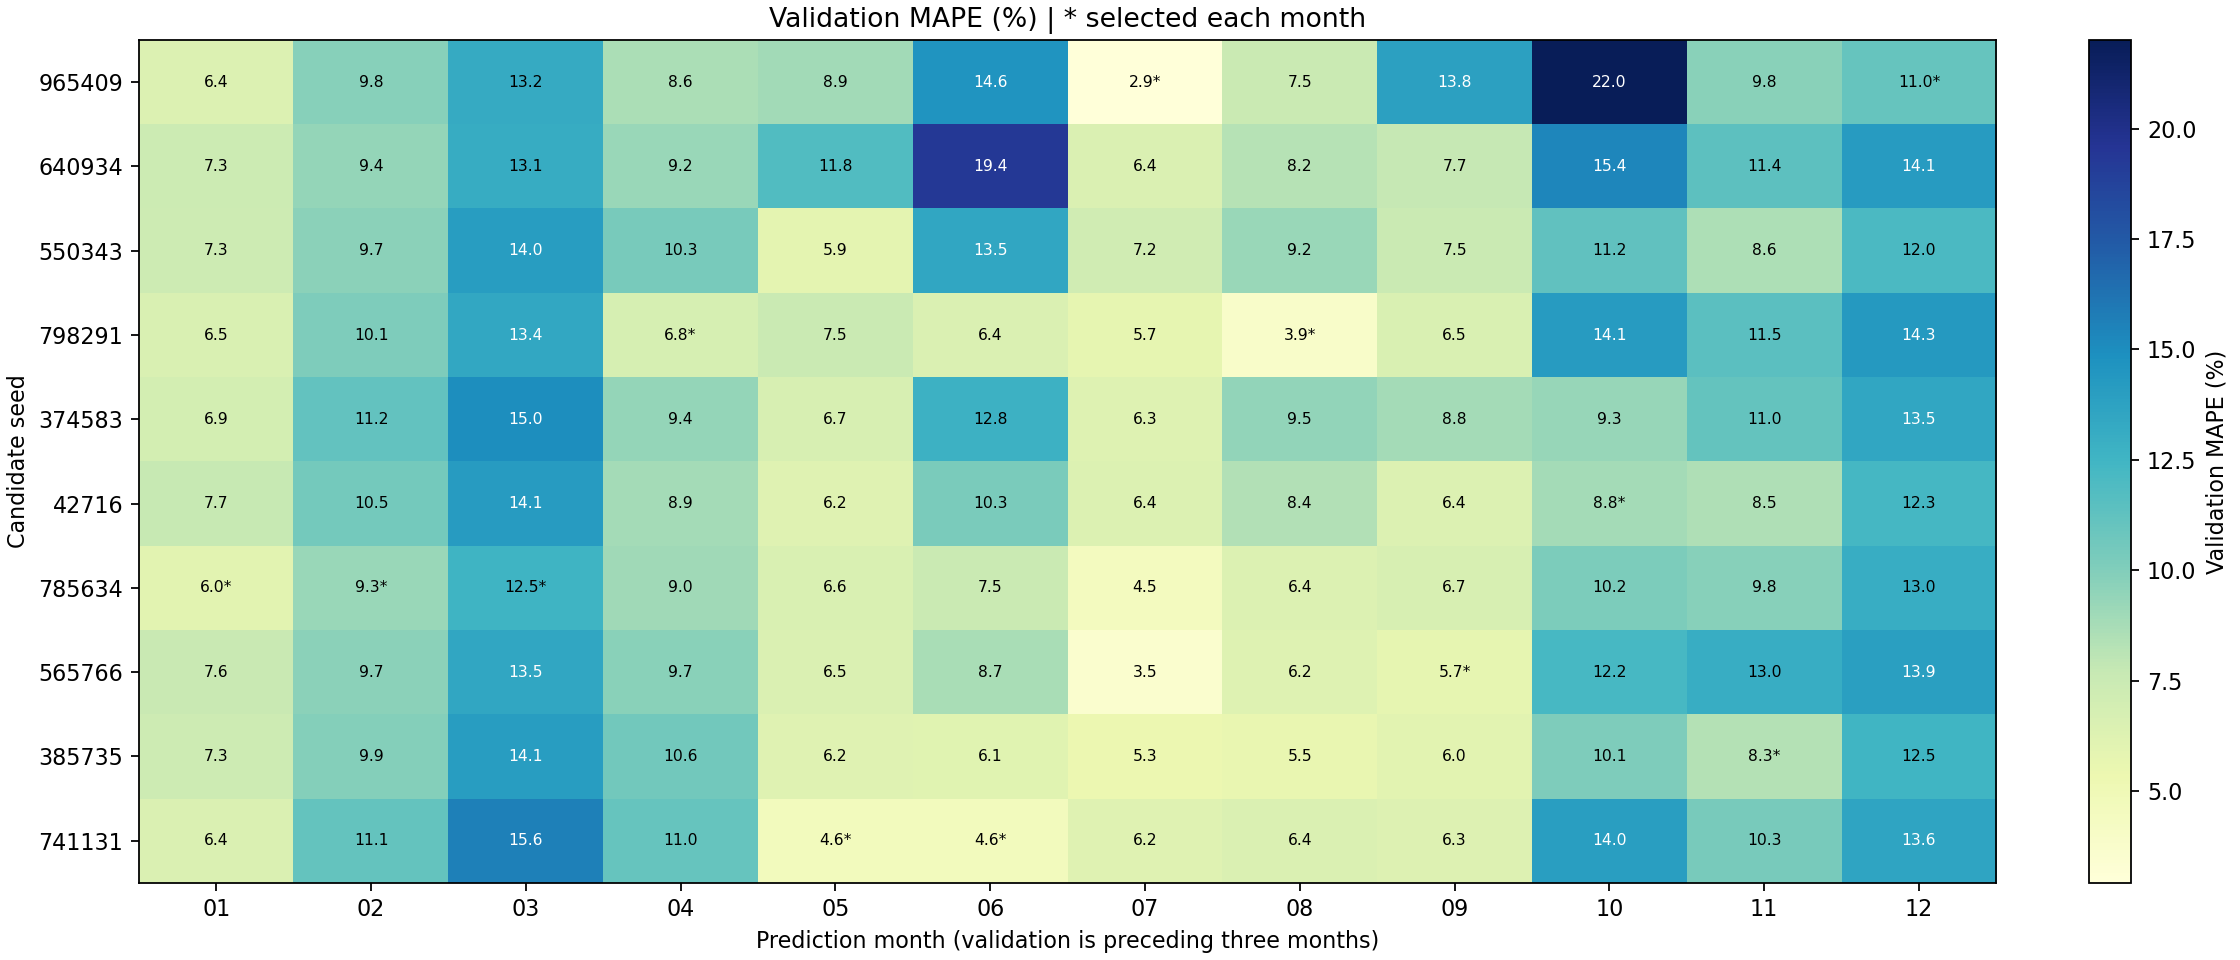

In [3]:
fig,axes=plt.subplots(2,1,figsize=(14,9),constrained_layout=True)
axes[0].plot(stitched.Date,stitched.Actual,color='black',lw=1.8,label='Actual')
axes[0].plot(stitched.Date,stitched.Predicted,color='#009E73',lw=1.5,label='Monthly train / validate / select')
axes[0].plot(stitched.Date,stitched.Frozen_annual_prediction,color='#0072B2',lw=1.2,alpha=.8,label=f'January model frozen (seed {annual_seed})')
for d in pd.date_range('2020-02-01','2020-12-01',freq='MS'):axes[0].axvline(d,color='gray',alpha=.15)
axes[0].set(title='2020 monthly stitched predictions | Stacking | 100 epochs per stage',ylabel='Price (dataset units)');axes[0].legend();axes[0].grid(alpha=.2)
positions=np.arange(12)
axes[1].bar(positions-.18,monthly.Test_MAPE,width=.35,color='#009E73',label='Monthly selection')
axes[1].bar(positions+.18,monthly.Frozen_annual_MAPE,width=.35,color='#0072B2',label='Frozen annual model')
axes[1].set(xticks=positions,xticklabels=[m[-2:] for m in monthly.Month],xlabel='2020 month',ylabel='Test MAPE (%)',title='Monthly test error');axes[1].legend();axes[1].grid(axis='y',alpha=.2)
fig.savefig(OUT/'stitched_comparison.png',dpi=160);plt.close(fig);display(Image(filename=str(OUT/'stitched_comparison.png')))
fig,axes=plt.subplots(4,3,figsize=(15,12),constrained_layout=True)
for ax,(month,g) in zip(axes.flat,stitched.groupby('Month')):
    ax.plot(g.Date,g.Actual,color='black',lw=1.5,label='Actual');ax.plot(g.Date,g.Predicted,color='#009E73',lw=1.3,label='Selected')
    r=monthly[monthly.Month==month].iloc[0]
    ax.set(title=f'{month} | seed {int(r.Selected_seed)} | MAPE {r.Test_MAPE:.2f}%');ax.grid(alpha=.2);ax.tick_params(axis='x',rotation=30,labelsize=7)
axes[0,0].legend();fig.savefig(OUT/'monthly_panels.png',dpi=140);plt.close(fig);display(Image(filename=str(OUT/'monthly_panels.png')))
rankmap=validation.pivot(index='Seed',columns='Month',values='MAPE').reindex(SEEDS)
fig,ax=plt.subplots(figsize=(14,6),constrained_layout=True)
im=ax.imshow(rankmap.to_numpy(),aspect='auto',cmap='YlGnBu')
ax.set(xticks=np.arange(12),xticklabels=[m[-2:] for m in rankmap.columns],yticks=np.arange(10),yticklabels=SEEDS,xlabel='Prediction month (validation is preceding three months)',ylabel='Candidate seed',title='Validation MAPE (%) | * selected each month')
for j,m in enumerate(rankmap.columns):
    chosen=int(selection.loc[selection.Month==m,'Selected_seed'].iloc[0])
    for i,s in enumerate(SEEDS):ax.text(j,i,f'{rankmap.loc[s,m]:.1f}'+('*' if s==chosen else ''),ha='center',va='center',fontsize=7,color='white' if rankmap.loc[s,m]>rankmap.to_numpy().max()*.6 else 'black')
fig.colorbar(im,ax=ax,label='Validation MAPE (%)');fig.savefig(OUT/'validation_heatmap.png',dpi=160);plt.close(fig);display(Image(filename=str(OUT/'validation_heatmap.png')))


## 逐月回测结论

| 月份 | 选中种子 | 前三月验证MAPE | 当月测试MAPE | 年初冻结模型MAPE |
|---|---:|---:|---:|---:|
|2020-01|785634|6.026%|12.442%|12.442%|
|2020-02|785634|9.254%|14.295%|12.933%|
|2020-03|785634|12.547%|5.680%|7.968%|
|2020-04|798291|6.791%|3.745%|3.195%|
|2020-05|741131|4.583%|3.650%|5.318%|
|2020-06|741131|4.616%|13.363%|8.446%|
|2020-07|965409|2.915%|13.347%|5.645%|
|2020-08|798291|3.853%|7.689%|14.355%|
|2020-09|565766|5.680%|14.598%|22.219%|
|2020-10|42716|8.844%|12.456%|20.554%|
|2020-11|385735|8.294%|21.183%|31.879%|
|2020-12|965409|10.996%|16.195%|30.328%|

| 方案 | 全年逐记录MAPE | 12个月等权MAPE | 全年原尺度MSE |
|---|---:|---:|---:|
|逐月训练、前三个月验证选种子|11.5270%|11.5536%|0.7955|
|1月选中模型全年冻结|14.5383%|14.6069%|1.7473|

逐月方案全年逐记录MAPE改善**3.0113个百分点**。1月两方案模型相同；3、5、8—12月改善，2、4、6、7月恶化，尤其6、7月分别比冻结方案高4.92、7.70个百分点。改进主要体现在8—12月，但11月仍有21.18%的测试MAPE，说明方法没有解决所有跨期误差。

本次结果支持“逐月更新整个训练与验证选择流程，比年初选择一次后全年固定更适应这一年”，不能单独证明选种子有效：训练数据每月扩展、验证窗口更新、模型选择变化同时发生。也不能据此认定3个月窗口优于6个月，6个月尚未运行。

10个候选随机种子已在结果出现前抽取、排除旧种子并固定到代码及配置；没有事后重抽种子。每月的selection.json先于当月评价写入；检查训练<验证<测试且三个区间无重叠；全年拼接覆盖原数据2020年全部271条记录、无重复无缺失；1月冻结对照与滚动方案预测一致（浮点容差1e-6）。

每个预测月前有3个月专用于验证且不参与本月训练。例如12月训练截至8月底，验证9—11月。选中后不重训是本次固定方案，意味着最新三个月用于选模型而非更新权重。

**仍需保留时间可用性限制**：模型使用测试日同日的宏观/金铜输入，这不是在月初提前生成整个月预测，而是冻结当月模型后用当日输入作回测。2020年也已用于此前实验，所以本次仍是开发期历史检验。

结果位于 `results/mlp_monthly_validation_12`，包括全年拼接图、12个月小图、验证热力图、逐月边界、候选验证排名、固定选择记录、各候选测试结果、240个阶段权重和训练历史。


---

目前没有把验证集也纳入训练,可能损失了一点信息,我们在进行一次比对.

---